# Machine Learning Assignment 2
## Breast Cancer Diagnostic Classification

**Student Name:** Divyendu Shekhar  
**BITS ID:** 2025AC05281  
**BITS Email:** 2025ac05281@wilp.bits-pilani.ac.in  
**Programme:** M.Tech (Artificial Intelligence and Machine Learning)  
**Section:** 2  

This notebook implements and compares the five classification models explicitly listed in the assignment. The target convention used throughout is **0 = Benign** and **1 = Malignant**.

## 1. Assignment Objective

The project uses a public binary-classification dataset with more than 500 instances and more than 12 features. The same leakage-free training and test partitions are used for all models. The following metrics are calculated for every model:

- Accuracy
- AUC Score
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

The supplied `test_data.csv` is treated as the unseen test set. Its exact records are removed from the public source dataset before training.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda value: f'{value:.4f}')

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebook':
    PROJECT_ROOT = PROJECT_ROOT.parent

TEST_DATA_PATH = PROJECT_ROOT / 'test_data.csv'
MODEL_DIR = PROJECT_ROOT / 'model'
RESULTS_DIR = PROJECT_ROOT / 'results'
RANDOM_STATE = 42
TARGET_COLUMN = 'diagnosis'
CLASS_LABELS = {0: 'Benign', 1: 'Malignant'}

print('Project root:', PROJECT_ROOT)
print('Test data path:', TEST_DATA_PATH)

Project root: /mnt/data/ML_Assignment_2_Divyendu_Shekhar
Test data path: /mnt/data/ML_Assignment_2_Divyendu_Shekhar/test_data.csv


## 2. Load the Public Dataset

The Breast Cancer Wisconsin (Diagnostic) dataset is loaded from scikit-learn. It is a local copy of the UCI dataset and therefore does not require an internet download.

The scikit-learn target is `0 = malignant` and `1 = benign`. It is reversed below so that malignant is the positive class (`1`) for Precision, Recall, F1, and AUC.

In [2]:
dataset = load_breast_cancer(as_frame=True)
source_features = dataset.data.copy()
source_target = (1 - dataset.target.astype(int)).rename(TARGET_COLUMN)
feature_names = list(source_features.columns)

print('Total source instances:', len(source_features))
print('Number of input features:', len(feature_names))
print('Missing feature values:', int(source_features.isna().sum().sum()))
print('Class distribution (0=Benign, 1=Malignant):')
display(source_target.value_counts().sort_index().rename('count').to_frame())

display(source_features.head())

Total source instances: 569
Number of input features: 30
Missing feature values: 0
Class distribution (0=Benign, 1=Malignant):


,count
diagnosis,
0,357
1,212


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


## 3. Load and Validate the Supplied Test Data

The uploaded assignment file contains 114 labelled test records. The file has 30 numeric feature columns plus the target column `diagnosis`.

In [3]:
test_data = pd.read_csv(TEST_DATA_PATH)
required_columns = feature_names + [TARGET_COLUMN]

assert list(test_data.columns) == required_columns, 'Unexpected test-data schema.'
assert not test_data.isna().any().any(), 'Test data contains missing values.'
assert set(test_data[TARGET_COLUMN]) == {0, 1}, 'Target must contain 0 and 1.'

print('Test-data shape:', test_data.shape)
print('Test class distribution:')
display(test_data[TARGET_COLUMN].value_counts().sort_index().rename('count').to_frame())
display(test_data.head())

Test-data shape: (114, 31)
Test class distribution:


,count
diagnosis,
0,72
1,42


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,19.7900,25.1200,130.4000,1192.0000,0.1015,0.1589,0.2545,0.1149,0.2202,0.0611,0.4953,1.1990,2.7650,63.3300,0.0050,0.0318,0.0476,0.0104,0.0158,0.0032,22.6300,33.5800,148.7000,1589.0000,0.1275,0.3861,0.5673,0.1732,0.3305,0.0847,1
1,11.9300,21.5300,76.5300,438.6000,0.0977,0.0785,0.0333,0.0201,0.1688,0.0619,0.3118,0.9227,2.0000,24.7900,0.0078,0.0251,0.0184,0.0077,0.0128,0.0039,13.6700,26.1500,87.5400,583.0000,0.1500,0.2399,0.1503,0.0725,0.2438,0.0854,0
2,11.2000,29.3700,70.6700,386.0000,0.0745,0.0356,0.0000,0.0000,0.1060,0.0550,0.3141,3.8960,2.0410,22.8100,0.0076,0.0089,0.0000,0.0000,0.0199,0.0018,11.9200,38.3000,75.1900,439.6000,0.0927,0.0549,0.0000,0.0000,0.1566,0.0590,0
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,1
4,13.7800,15.7900,88.3700,585.9000,0.0882,0.0672,0.0106,0.0099,0.1405,0.0585,0.3563,0.4833,2.2350,29.3400,0.0064,0.0116,0.0077,0.0057,0.0123,0.0026,15.2700,17.5000,97.9000,706.6000,0.1072,0.1071,0.0352,0.0331,0.1859,0.0681,0


## 4. Create a Leakage-Free Training Partition

Each test row is matched against the source dataset using all 30 feature values rounded to eight decimal places. The matching source rows are excluded from training. The models are fitted on the remaining records only.

In [4]:
source_match = source_features.round(8).reset_index(names='source_index')
test_match = test_data[feature_names].round(8).reset_index(names='test_row')
matched_rows = test_match.merge(
    source_match,
    on=feature_names,
    how='left',
    validate='one_to_one',
)

assert matched_rows['source_index'].notna().all(), 'A test row was not found in the source data.'
test_source_indices = matched_rows['source_index'].astype(int).tolist()

expected_test_labels = source_target.loc[test_source_indices].reset_index(drop=True)
provided_test_labels = test_data[TARGET_COLUMN].reset_index(drop=True)
assert expected_test_labels.equals(provided_test_labels), 'Test labels do not match source labels.'

training_mask = ~source_features.index.isin(test_source_indices)
X_train = source_features.loc[training_mask, feature_names].copy()
y_train = source_target.loc[training_mask].copy()
X_test = test_data[feature_names].copy()
y_test = test_data[TARGET_COLUMN].copy()

print('Training shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Total rows accounted for:', len(X_train) + len(X_test))
print('Training class distribution:')
display(y_train.value_counts().sort_index().rename('count').to_frame())

Training shape: (455, 30)
Test shape: (114, 30)
Total rows accounted for: 569
Training class distribution:


,count
diagnosis,
0,285
1,170


## 5. Define the Classification Models

Standardization is included inside pipelines for Logistic Regression, kNN, and Gaussian Naive Bayes. This ensures that scaling parameters are learned from the training data only. Tree-based models do not require feature scaling.

In [5]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    ),
    'kNN': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=7, weights='distance')),
    ]),
    'Naive Bayes': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', GaussianNB()),
    ]),
    'Random Forest (Ensemble)': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

print('Models to be trained:')
for number, model_name in enumerate(models, start=1):
    print(f'{number}. {model_name}')

Models to be trained:
1. Logistic Regression
2. Decision Tree
3. kNN
4. Naive Bayes
5. Random Forest (Ensemble)


## 6. Train Every Model and Calculate the Required Metrics

In [6]:
metric_rows = []
model_outputs = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test).astype(int)
    probabilities = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_test, predictions),
        'AUC': roc_auc_score(y_test, probabilities),
        'Precision': precision_score(y_test, predictions, zero_division=0),
        'Recall': recall_score(y_test, predictions, zero_division=0),
        'F1': f1_score(y_test, predictions, zero_division=0),
        'MCC': matthews_corrcoef(y_test, predictions),
    }

    metric_rows.append({'ML Model Name': model_name, **metrics})
    model_outputs[model_name] = {
        'model': model,
        'predictions': predictions,
        'probabilities': probabilities,
        'confusion_matrix': confusion_matrix(y_test, predictions, labels=[0, 1]),
        'classification_report': classification_report(
            y_test,
            predictions,
            labels=[0, 1],
            target_names=['Benign', 'Malignant'],
            output_dict=True,
            zero_division=0,
        ),
    }

comparison = pd.DataFrame(metric_rows)[
    ['ML Model Name', 'Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']
]
comparison

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9561,0.9970,1.0000,0.8810,0.9367,0.9076
1,Decision Tree,0.8947,0.8545,0.8947,0.8095,0.8500,0.7715
2,kNN,0.9386,0.9907,0.9730,0.8571,0.9114,0.8688
3,Naive Bayes,0.9035,0.9854,0.9189,0.8095,0.8608,0.7911
4,Random Forest (Ensemble),0.9649,0.9955,0.9750,0.9286,0.9512,0.9245


## 7. Model Comparison Table

The table below is the comparison table required in the assignment. Values are displayed to four decimal places.

In [7]:
display(
    comparison.style
    .format({metric: '{:.4f}' for metric in ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']})
    .hide(axis='index')
)

winner_row = comparison.sort_values(
    ['MCC', 'F1', 'AUC', 'Accuracy'],
    ascending=False,
).iloc[0]
print('Overall winner:', winner_row['ML Model Name'])
print('Winner MCC:', f"{winner_row['MCC']:.4f}")

ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.9561,0.9970,1.0000,0.8810,0.9367,0.9076
Decision Tree,0.8947,0.8545,0.8947,0.8095,0.8500,0.7715
kNN,0.9386,0.9907,0.9730,0.8571,0.9114,0.8688
Naive Bayes,0.9035,0.9854,0.9189,0.8095,0.8608,0.7911
Random Forest (Ensemble),0.9649,0.9955,0.9750,0.9286,0.9512,0.9245


Overall winner: Random Forest (Ensemble)
Winner MCC: 0.9245


## 8. Performance Comparison Chart

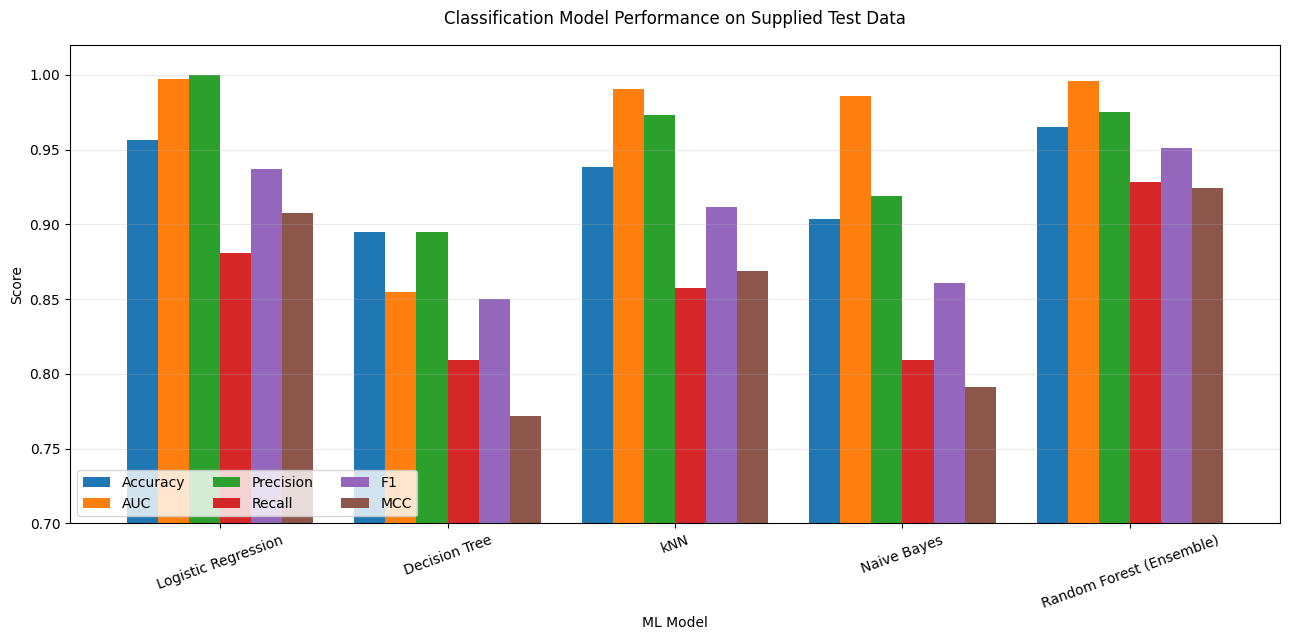

In [8]:
plot_frame = comparison.set_index('ML Model Name')[
    ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']
]
axis = plot_frame.plot(kind='bar', figsize=(13, 6.5), width=0.82)
axis.set_title('Classification Model Performance on Supplied Test Data', pad=15)
axis.set_xlabel('ML Model')
axis.set_ylabel('Score')
axis.set_ylim(0.70, 1.02)
axis.tick_params(axis='x', rotation=20)
axis.grid(axis='y', alpha=0.25)
axis.legend(loc='lower left', ncol=3)
plt.tight_layout()
plt.show()

## 9. ROC Curves

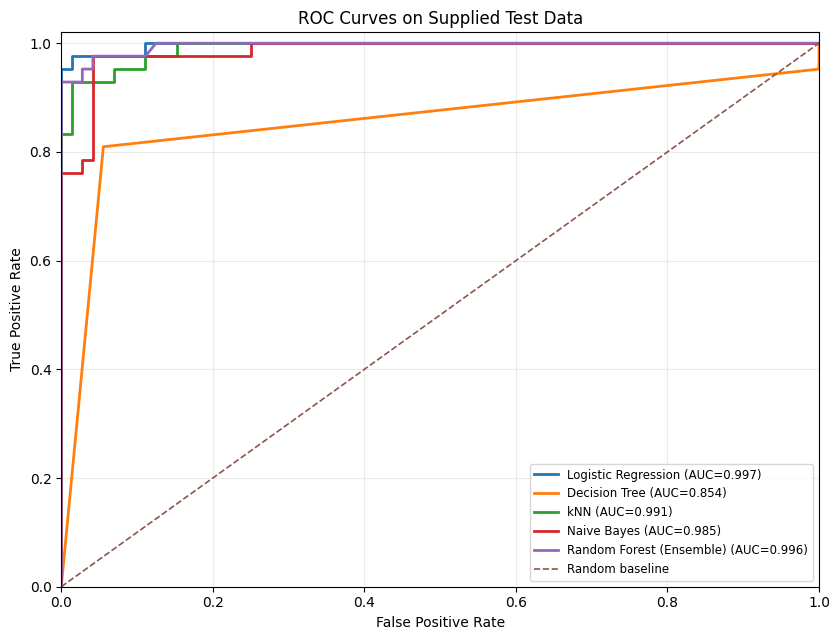

In [9]:
plt.figure(figsize=(8.5, 6.5))
for model_name, output in model_outputs.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test, output['probabilities']
    )
    auc_value = roc_auc_score(y_test, output['probabilities'])
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=f'{model_name} (AUC={auc_value:.3f})',
    )

plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1.2, label='Random baseline')
plt.title('ROC Curves on Supplied Test Data')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(alpha=0.25)
plt.legend(loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.show()

## 10. Confusion Matrices

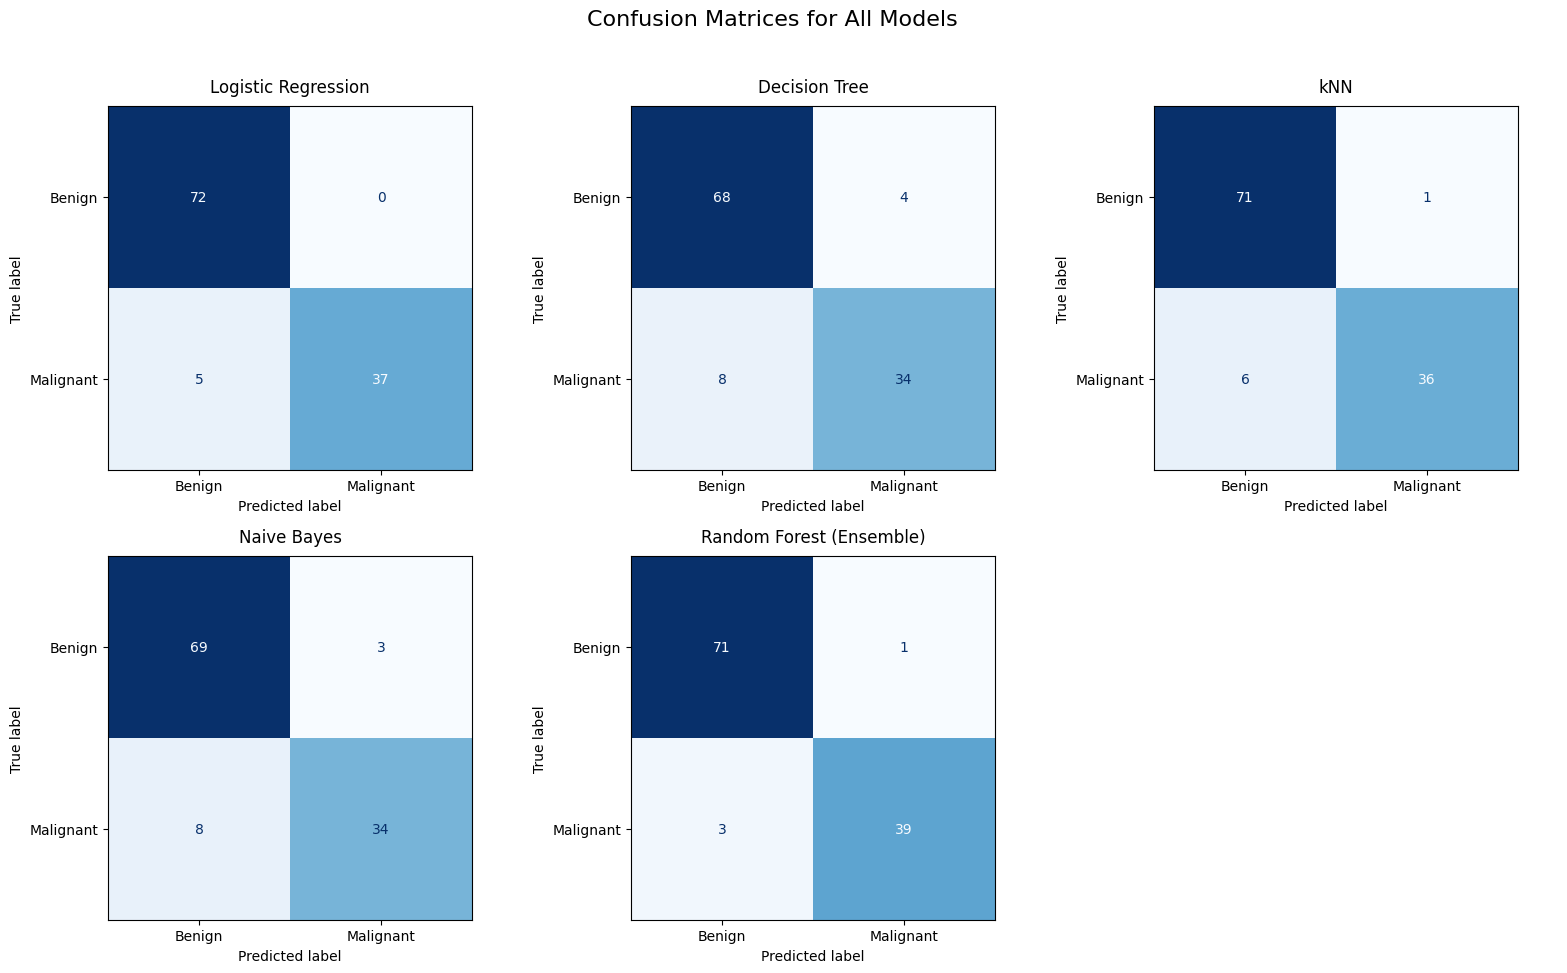

In [10]:
figure, axes = plt.subplots(2, 3, figsize=(16, 9.5))
axes = axes.flatten()

for axis, (model_name, output) in zip(axes, model_outputs.items()):
    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=output['confusion_matrix'],
        display_labels=['Benign', 'Malignant'],
    )
    display_matrix.plot(ax=axis, cmap='Blues', colorbar=False, values_format='d')
    axis.set_title(model_name, pad=10)

axes[-1].axis('off')
figure.suptitle('Confusion Matrices for All Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 11. Classification Reports

In [11]:
for model_name, output in model_outputs.items():
    print('=' * 76)
    print(model_name)
    print('=' * 76)
    report_frame = pd.DataFrame(output['classification_report']).transpose()
    display(report_frame.round(4))

Logistic Regression


,precision,recall,f1-score,support
Benign,0.9351,1.0000,0.9664,72.0000
Malignant,1.0000,0.8810,0.9367,42.0000
accuracy,0.9561,0.9561,0.9561,0.9561
macro avg,0.9675,0.9405,0.9516,114.0000
weighted avg,0.9590,0.9561,0.9555,114.0000


Decision Tree


,precision,recall,f1-score,support
Benign,0.8947,0.9444,0.9189,72.0000
Malignant,0.8947,0.8095,0.8500,42.0000
accuracy,0.8947,0.8947,0.8947,0.8947
macro avg,0.8947,0.8770,0.8845,114.0000
weighted avg,0.8947,0.8947,0.8935,114.0000


kNN


,precision,recall,f1-score,support
Benign,0.9221,0.9861,0.9530,72.0000
Malignant,0.9730,0.8571,0.9114,42.0000
accuracy,0.9386,0.9386,0.9386,0.9386
macro avg,0.9475,0.9216,0.9322,114.0000
weighted avg,0.9408,0.9386,0.9377,114.0000


Naive Bayes


,precision,recall,f1-score,support
Benign,0.8961,0.9583,0.9262,72.0000
Malignant,0.9189,0.8095,0.8608,42.0000
accuracy,0.9035,0.9035,0.9035,0.9035
macro avg,0.9075,0.8839,0.8935,114.0000
weighted avg,0.9045,0.9035,0.9021,114.0000


Random Forest (Ensemble)


,precision,recall,f1-score,support
Benign,0.9595,0.9861,0.9726,72.0000
Malignant,0.9750,0.9286,0.9512,42.0000
accuracy,0.9649,0.9649,0.9649,0.9649
macro avg,0.9672,0.9573,0.9619,114.0000
weighted avg,0.9652,0.9649,0.9647,114.0000


## 12. Observations

| ML Model | Observation |
|---|---|
| Logistic Regression | Achieved the highest AUC (0.9970) and perfect malignant-class precision (1.0000). It produced no false positives, but five malignant records were missed, reducing recall to 0.8810. |
| Decision Tree | Easy to interpret, but it achieved the lowest AUC (0.8545) and MCC (0.7715). It made 12 incorrect predictions, showing that one tree was less stable on this test partition. |
| kNN | Standardization allowed kNN to perform strongly. It achieved AUC 0.9907 and precision 0.9730, but missed six malignant records. |
| Naive Bayes | Achieved high AUC (0.9854), but lower accuracy and recall. Correlation among radius, perimeter, area, and related measurements weakens the conditional-independence assumption. |
| Random Forest (Ensemble) | Achieved the highest Accuracy (0.9649), Recall (0.9286), F1 (0.9512), and MCC (0.9245). It made only one false-positive and three false-negative predictions. |

### Overall Winner

**Random Forest (Ensemble)** is the overall winner. MCC is used as the primary selection criterion because it includes true positives, true negatives, false positives, and false negatives in one balanced score. Random Forest also leads on Accuracy, Recall, and F1.

## 13. Verify Saved Repository Artifacts

The repository already contains the serialized models and result files generated by `model/train_models.py`. This cell verifies that each required artifact exists.

In [12]:
expected_artifacts = [
    MODEL_DIR / 'logistic_regression.joblib',
    MODEL_DIR / 'decision_tree.joblib',
    MODEL_DIR / 'knn.joblib',
    MODEL_DIR / 'naive_bayes.joblib',
    MODEL_DIR / 'random_forest_ensemble.joblib',
    MODEL_DIR / 'model_metrics.json',
    RESULTS_DIR / 'model_comparison.csv',
    PROJECT_ROOT / 'test_data.csv',
]

artifact_check = pd.DataFrame({
    'Artifact': [str(path.relative_to(PROJECT_ROOT)) for path in expected_artifacts],
    'Exists': [path.exists() for path in expected_artifacts],
})
display(artifact_check)
assert artifact_check['Exists'].all(), 'One or more required artifacts are missing.'

,Artifact,Exists
0,model/logistic_regression.joblib,True
1,model/decision_tree.joblib,True
2,model/knn.joblib,True
3,model/naive_bayes.joblib,True
4,model/random_forest_ensemble.joblib,True
5,model/model_metrics.json,True
6,results/model_comparison.csv,True
7,test_data.csv,True


## 14. Streamlit Deployment

Run the following command from the project root:

```bash
streamlit run app.py
```

The app supports CSV upload, model selection, all six required metrics, confusion matrices, classification reports, predictions, model comparison, and downloadable results.

The assignment must be executed once on BITS Virtual Lab. A genuine screenshot from that execution must be inserted into the final submission PDF.